In [15]:
import numpy as np 
import matplotlib.pyplot as plt
import mglearn

plt.rcParams['font.sans-serif']=['Micorsoft YaHei','SimHei','DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False 

X,y=mglearn.datasets.make_wave(n_samples=60)

print("数据形状:",X.shape)
print("前5个目标值:",y[:5])

数据形状: (60, 1)
前5个目标值: [-1.18073311  0.50015912  0.13772889  1.17396178 -1.32035898]


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)

lr = LinearRegression()

lr.fit(X_train,y_train)

print("截距(b):",lr.intercept_)

print(f"训练集 R²:{lr.score(X_train,y_train):.3f}")
print(f"测试集 R²:{lr.score(X_test,y_test):.3f}")

截距(b): -0.03180434302675973
训练集 R²:0.670
测试集 R²:0.659


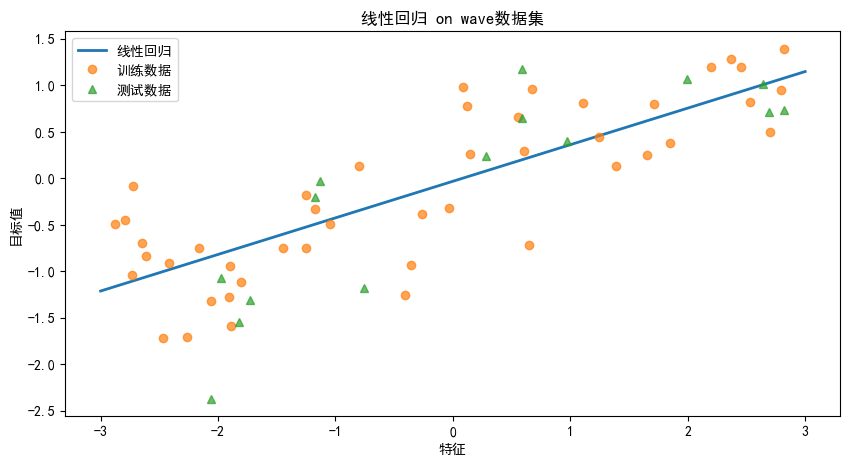

In [17]:
line = np.linspace(-3,3,1000).reshape(-1,1)

plt.figure(figsize=(10,5))

plt.plot(line,lr.predict(line),label='线性回归',linewidth=2)
plt.plot(X_train,y_train,'o',label='训练数据',alpha=0.7)
plt.plot(X_test,y_test,'^',label='测试数据',alpha=0.7)

plt.xlabel('特征')
plt.ylabel('目标值')
plt.title('线性回归 on wave数据集')
plt.legend()
plt.show()

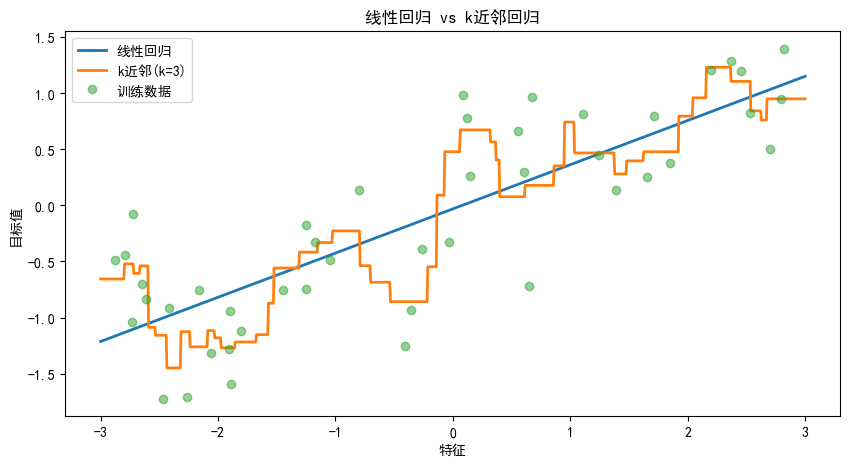

模型对比
线性回归 - 训练R²:0.670,测试R²:0.659
k近邻(3)-训练R²:0.815,测试R²:0.748


In [18]:
from sklearn.neighbors import KNeighborsRegressor

knn=KNeighborsRegressor(n_neighbors=3)
knn.fit(X_train,y_train)

plt.figure(figsize=(10,5))
plt.plot(line,lr.predict(line),label='线性回归',linewidth=2)
plt.plot(line,knn.predict(line),label='k近邻(k=3)',linewidth=2)
plt.plot(X_train,y_train,'o',label='训练数据',alpha=0.5)

plt.xlabel('特征')
plt.ylabel('目标值')
plt.title('线性回归 vs k近邻回归')
plt.legend()
plt.show()

print("="*40)
print("模型对比")
print("="*40)
print(f"线性回归 - 训练R²:{lr.score(X_train,y_train):.3f},测试R²:{lr.score(X_test,y_test):.3f}")
print(f"k近邻(3)-训练R²:{knn.score(X_train,y_train):.3f},测试R²:{knn.score(X_test,y_test):.3f}")

In [19]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train,y_train)

print("="*40)
print("岭回归(Ridge)")
print("="*40)
print(f"斜率:{ridge.coef_}")
print(f"截距:{ridge.intercept_}")
print(f"训练集 R²:{ridge.score(X_train, y_train):.3f}")
print(f"测试集 R²:{ridge.score(X_test,y_test):.3f}")

print("\n"+"="*40)
print("线性回归 - 岭回归")
print(f"线性回归 - 测试R²:{lr.score(X_test,y_test):.3f}")
print(f"岭回归   - 测试R²:{ridge.score(X_test,y_test):.3f}")

岭回归(Ridge)
斜率:[0.39130987]
截距:-0.03259061499008391
训练集 R²:0.670
测试集 R²:0.658

线性回归 - 岭回归
线性回归 - 测试R²:0.659
岭回归   - 测试R²:0.658


In [13]:
alpha_values=[0.001,0.1,1,10,100]

print("\n"+"="*50)
print("不同alpha值的岭回归对比")
print("="*50)
print(f"{'alpha':<10}{'训练R²':<10}{'测试R²':<10}")

for alpha in alpha_values:
    ridge_temp = Ridge(alpha=alpha)
    ridge_temp.fit(X_train,y_train)
    print(f"{alpha:<10}{ridge_temp.score(X_train,y_train):<10.3f}{ridge_temp.score(X_test,y_test):<10.3f}")


不同alpha值的岭回归对比
alpha     训练R²      测试R²      
0.001     0.670     0.659     
0.1       0.670     0.659     
1         0.670     0.658     
10        0.667     0.643     
100       0.564     0.499     


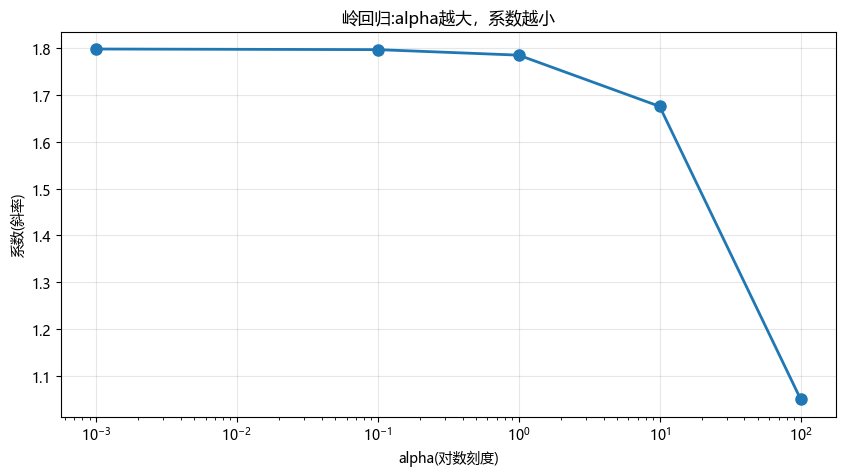

In [39]:
plt.figure(figsize=(10,5))

ridge_coefs = []

for alpha in alpha_values:
    ridge_temp = Ridge(alpha=alpha)
    ridge_temp.fit(X_train,y_train)
    ridge_coefs.append(ridge_temp.coef_[0])
plt.plot(alpha_values,ridge_coefs,'o-',linewidth=2,markersize=8)
plt.xscale('log')
plt.xlabel('alpha(对数刻度)')
plt.ylabel('系数(斜率)')
plt.title('岭回归:alpha越大，系数越小')
plt.grid(True,alpha=0.3)
plt.show()

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 解决中文显示
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
np.random.seed(42)
n_samples=200
n_features = 10

true_coef = np.array([1.8,-2.2,0.9,0.6,0,0,0,0,0,0])

X = np.random.randn(n_samples,n_features)
y = np.dot(X,true_coef) + np.random.randn(n_samples)*0.8

print("="*50)
print("模拟数据集")
print("="*50)
print(f"样本数:{n_samples}")
print(f"特征数:{n_features}")
print(f"真实系数:{true_coef}")
print("说明:只有前4个特征（x1-x4）与房价相关，后6个是噪声特征")
from sklearn.linear_model import Lasso 
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr= LinearRegression()
lr.fit(X_train_scaled,y_train)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled,y_train)

print("\n"+"="*50)
print("三种模型性能对比")
print("="*50)
print(f"{'模型':<12}{'训练R²':<12}")
print("-"*40)
print(f"{'线性回归':<12}{lr.score(X_train_scaled,y_train):<12.4f}{lr.score(X_test_scaled,y_test):<12.4f}")
print(f"{'岭回归':<12}{ridge.score(X_train_scaled,y_train):<12.4f}{ridge.score(X_test_scaled,y_test):<12.4f}")
print(f"{'Lasso':<12}{lasso.score(X_train_scaled,y_train):<12.4f}{lasso.score(X_test_scaled,y_test):<12.4f}")

模拟数据集
样本数:200
特征数:10
真实系数:[ 1.8 -2.2  0.9  0.6  0.   0.   0.   0.   0.   0. ]
说明:只有前4个特征（x1-x4）与房价相关，后6个是噪声特征

三种模型性能对比
模型          训练R²        
----------------------------------------
线性回归        0.9458      0.9524      
岭回归         0.9458      0.9521      


ValueError: X has 10 features, but Lasso is expecting 1 features as input.


三种模型性能对比
模型          训练R²        
----------------------------------------
线性回归        0.9458      0.9524      
岭回归         0.9458      0.9521      


ValueError: X has 10 features, but Lasso is expecting 1 features as input.